# PyRoss Stochastic TSI testing

We test here the stochastic simulation of TSI-SIR from "pyross/tsi/stochastic.pyx".

The method used in a Monte-Carlo tau-leaping algorithm that uses binomial distributions rather than classic Poisson distributions.


In [1]:
### Imports ###
import pyross.tsi as pyrosstsi
import numpy as np

import time

import matplotlib.pyplot as plt
import matplotlib as mpl

### Matplotlib settings ###
figsz_x = 10
mpl.rc('figure', figsize=(figsz_x, figsz_x/1.62))
mpl.rc('lines', linewidth=2.)
mpl.rc('font', size=14)
mpl.rc('legend', fontsize='large')
mpl.rc('axes', titlesize='x-large', labelsize='large')

### Run stochastic (MC) binomial $\tau$-leaping

We only use *one* age class to begin.

#### Parameters

- Population: $N=10^{3}$
- Number of age group = 1
- Time since infection *cut-off*: $\mathrm{tsi}_{\mathrm{max}} = 50$ days
- $\mathrm{d}\mathrm{tsi} = 1/2$ days
- Total length of the run: $T_{f} = 200$ days

We use: 
- $\beta(\tau) = \beta_{0}$
  with $\beta_{0} = 0.2$
- $\gamma(\tau) = \frac{\gamma_{0}}{\left( 1-e^{-\gamma_{0}(\tau_{\mathrm{max}}-\tau)} \right)}$, with $\gamma_{0} = 1/10. \, \mathrm{days}^{-1}$ and $\tau_{\mathrm{max}} = 50$ days.

  This function $\gamma(\tau)$ comes from a distribution of "residence time" in $I$ that is a truncated exponential. One should recover the regular Markovian SIR for $\tau_{\mathrm{max}} \to \infty$.

In [2]:
### Model Init from SIR class ###

# beta
def beta_fun(tsi, Ttsi, beta0):
    if tsi<Ttsi:
        return beta0
    else:
        return None

# gamma(tsi):
def gI_fun(tsi, Ttsi, g0):
    if g0>0:
        if tsi<Ttsi:
            return g0/(1-np.exp(-g0*(Ttsi-tsi))) # truncated exponential
        else:
            return None
    else:
        return 0

# beta and gI parameters
beta0 = 0.2
g0    = 1/10. #days^{-1}

# Time since infection: cut-off
Ttsi = 50 # days

# Population
N = int(1e3) # full population size
M = 1 # just one age group to begin
Ni = np.array([N]) # Array of age group sizes

# Contact Matrix
CM = np.zeros((M, M))
def contactMatrix(t):
    CM[0,0] = 1
    return CM

In [3]:
# tsi discretisation for stochastic sim
dtsi = 1/2. # days
kI = int(Ttsi/dtsi)

# Sort parameters into a dictionary
params_stoch = {'beta' : beta0,
              'gI'   : g0,
              'kI'   : kI,
              'Ttsi' : Ttsi,
              'M'    : M,
              'N'    : N,
              'Ni'   : Ni}

# Finally, instantiate the model
model_stoch = pyrosstsi.stochastic.SIR(params_stoch, beta_fun, gI_fun)

In [4]:
### Initial Conditions ###
# 5 infectives at t=0
I0_list = [(1, 0, 0), (2, 0, Ttsi/10.) ,(2, 0, Ttsi/2.)] # (number of infectives, age_class, tsi)
S0, I0 = model_stoch.set_IC(I0_list)

In [5]:
### Seed (random generator) ###
seed0 = -1 # not the same seed at each run !

### RUN simulation ###
# Total duration 
Tf = 200 # days

t1 = time.time()
data = model_stoch.simulate(S0, I0, contactMatrix, Tf, supplied_seed=seed0)
t2 = time.time()
# Let's print the time it took to run:
print('Time to run [#(time steps)={}, #(tsi compartments)={}]: {:1.3f} s'.format(len(data['S']), kI, t2-t1))

Time to run [#(time steps)=402, #(tsi compartments)=100]: 0.745 s


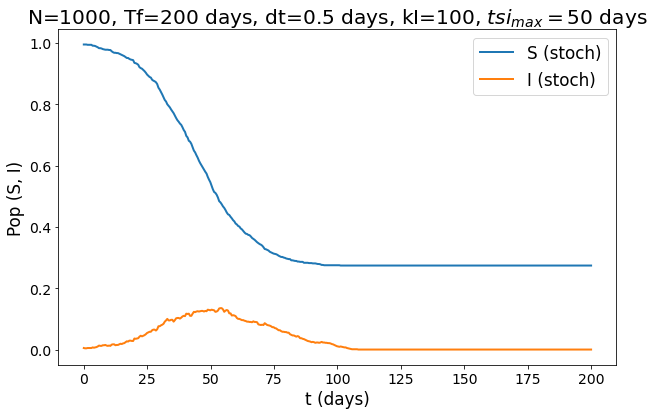

In [6]:
### PLOTS ###
t_list = np.linspace(0, Tf, len(data['S']))

Sagg_traj = []
Iagg_traj = []
for t in range(len(data['S'])):
    Sagg_traj.append(np.sum(data['S'][t])/float(N))
    Iagg_traj.append(np.sum(data['I'][t])/float(N))

plt.plot(t_list, Sagg_traj, label='S (stoch)')
plt.plot(t_list, Iagg_traj, label='I (stoch)')
plt.xlabel('t (days)')
plt.ylabel('Pop (S, I)')
plt.legend()

plt.title('N={}, Tf={} days, dt={} days, kI={}, $tsi_{{max}}={} $ days'.format(model_stoch.N, Tf, model_stoch.dtsi, model_stoch.kI, model_stoch.Ttsi));

### Comparison to deterministic TSI-SIR model

We compare the average trajectory from stochastic simulation to the deterministic solution.

#### Run deterministic

In [7]:
### Parameters ###

# Time since infection discretisation
dtsi_det = 0.1 #days
kI_det = int(Ttsi/dtsi_det)

# Same params as for stochastic but different kI (ie !=dtsi !)
params_det = params_stoch
params_det['kI'] = kI_det

# Instantiate model
model_det = pyrosstsi.deterministic.SIR(params_det, beta_fun, gI_fun)

# Same initial condition as stochastic
s0, i0 = model_det.set_IC(I0_list)

### Run ###
t1 = time.time()
data_det = model_det.simulate(s0, i0, contactMatrix, Tf)
t2 = time.time()
print('Time to run deterministic (kI={} tsi compartments, Nstep={}, dt={:1.3f}): {:1.3f} s'.format(model_det.kI, int(Tf/model_det.dtsi), dtsi, t2-t1))

Time to run deterministic (kI=500 tsi compartments, Nstep=2000, dt=0.500): 11.337 s


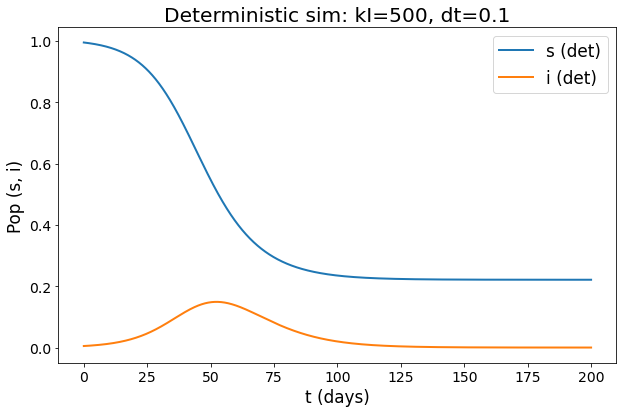

In [9]:
### PLOT ###
times = np.linspace(0, Tf, len(data_det['S']))

iagg_det_traj = []
# aggregated infected pop
for t in range(len(data_det['S'])):
    iagg_det_traj.append(np.sum(data_det['I'][t]))
    
plt.plot(times, data_det['S'], label='s (det)')
plt.plot(times, iagg_det_traj, label='i (det)')
plt.xlabel('t (days)')
plt.ylabel('Pop (s, i)')
plt.title('Deterministic sim: kI={}, dt={}'.format(model_det.kI, model_det.dtsi))
plt.legend()

### Now generate several stochastic trajectories and compare with deterministic one...

In [10]:
### Seed (random generator) ###
seed0 = -1 # not the same seed at each run !

### RUN simulation ###
total_runs = int(1e3)

dtsi = 1/2. # days
Nf = int(Tf/dtsi) + 1
kI = int(tsi_max/dtsi)

data_agg_list = []
t1 = time.time()
for run in range(total_runs):
    data = model.simulate(S0, I0, contactMatrix, Tf, Nf, supplied_seed=seed0)
    S_list = data['S']
    I_list = data['I']
    Sagg_list = []
    Iagg_list = []
    for t in range(Nf):
        Sagg = np.sum(S_list[t])/float(N)
        Iagg = np.sum(I_list[t])/float(N)
        Sagg_list.append(np.sum(Sagg))
        Iagg_list.append(np.sum(Iagg))
    data_agg = {'Sagg': Sagg_list,
               'Iagg': Iagg_list}
    data_agg_list.append(data_agg)
t2 = time.time()
# Let's print the time it took to run:
print('Time to run {} runs [#(time steps)={}, #(tsi compartments)={}]: {:1.3f} s'.format(total_runs, Nf, kI, t2-t1))

Time to run 1000 runs [#(time steps)=401, #(tsi compartments)=100]: 995.894 s


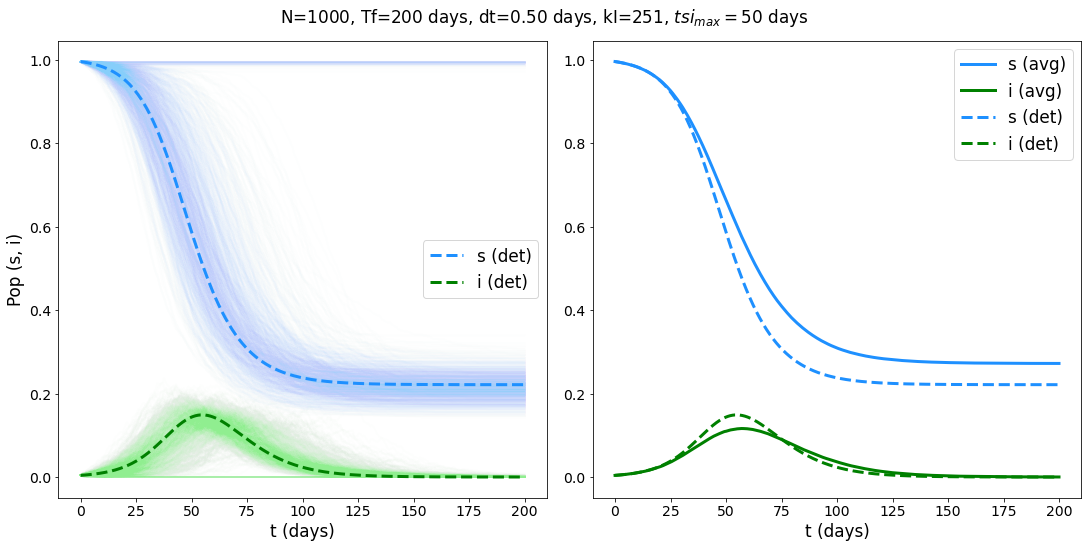

In [13]:
### PLOTS ###
fig, ax = plt.subplots(1,2, figsize=(15, 15/2.), constrained_layout=True)

t_list = np.linspace(0, Tf, Nf)

Savg_traj = np.zeros(Nf)
Iavg_traj = np.zeros(Nf)
for run in range(total_runs):
    data_agg = data_agg_list[run]
    Savg_traj += data_agg['Sagg']
    Iavg_traj += data_agg['Iagg']
    ax[0].plot(t_list, data_agg['Sagg'], color='lightskyblue', alpha=0.01)
    ax[0].plot(t_list, data_agg['Iagg'], color='lightgreen', alpha=0.01)
    
Savg_traj = [Savg_traj[k]/float(total_runs) for k in range(Nf)]
Iavg_traj = [Iavg_traj[k]/float(total_runs) for k in range(Nf)]


ax[1].plot(t_list, Savg_traj, color='dodgerblue', lw=3, label='s (avg)')
ax[1].plot(t_list, Iavg_traj, color='green', lw=3, label='i (avg)')

for p in range(2):
    ax[p].plot(times, s_det_traj, color='dodgerblue', ls='--', lw=3, label='s (det)')
    ax[p].plot(times, iagg_det_traj, color='green', ls='--', lw=3, label='i (det)')
    
    ax[p].set_xlabel('t (days)')

ax[0].set_ylabel('Pop (s, i)')
ax[0].legend()
ax[1].legend()

fig.suptitle('N={}, Tf={} days, dt={:1.2f} days, kI={}, $tsi_{{max}}={} $ days'.format(N, Tf, Tf/np.float(Nf), model.parameters['kI'], tsi_max));